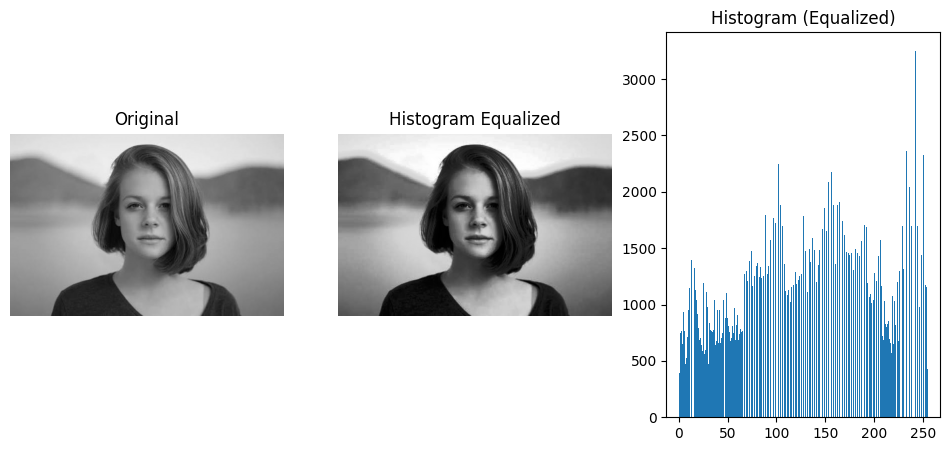

In [10]:
#PROGRAM-1
#Point Processing
#Histogram Equalization
import cv2
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread("/content/lq.jpg", 0)

# Safety check: cv2.imread() returns None (not an error) if the path is wrong
if img is None:
    raise FileNotFoundError(
        "Could not load '/content/lq.jpg'. "
        "Upload it first with: from google.colab import files; files.upload()"
    )

# Apply Histogram Equalization
he_img = cv2.equalizeHist(img)

# Display results
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.subplot(1,3,2)
plt.title("Histogram Equalized")
plt.imshow(he_img, cmap='gray')
plt.axis("off")
plt.subplot(1,3,3)
plt.title("Histogram (Equalized)")
plt.hist(he_img.ravel(), 256)
plt.show()

In [9]:
from google.colab import files
uploaded = files.upload()

Saving lq.jpg to lq.jpg


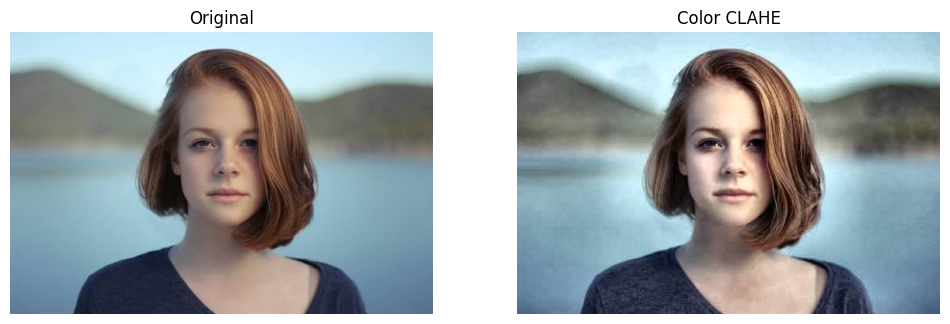

In [11]:
#Point Processing
#color Enhancement
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/lq.jpg")

if img is None:
    raise FileNotFoundError(
        "Could not load '/content/lq.jpg'. "
        "Upload it first with: from google.colab import files; files.upload()"
    )

img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
# Split Y, Cr, Cb
Y, Cr, Cb = cv2.split(img_ycrcb)
# CLAHE on Y channel
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
Y_clahe = clahe.apply(Y)
# Merge & convert back
img_clahe = cv2.merge((Y_clahe, Cr, Cb))
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YCrCb2BGR)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Color CLAHE")
plt.imshow(cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

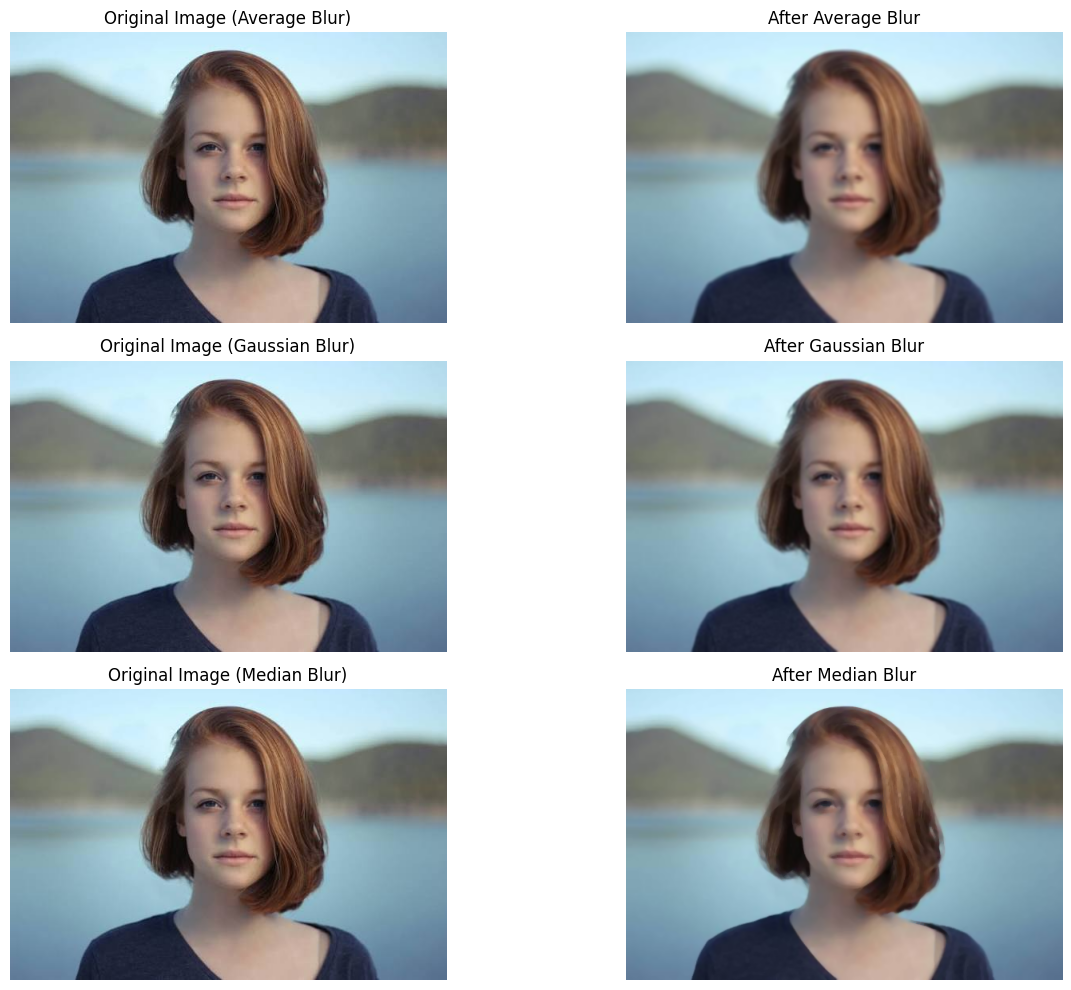

In [13]:
# Spatial Domain Filtering - Smoothing

import shutil
import cv2
import matplotlib.pyplot as plt

# Reuse lq.jpg for all three demos so this cell always works,
# even if the original 3 filenames were never uploaded.
shutil.copy("/content/lq.jpg", "/content/average blur ex.jpg")
shutil.copy("/content/lq.jpg", "/content/guassian blur.webp")
shutil.copy("/content/lq.jpg", "/content/median blur eg.png")

# ------------------------------
# Load 3 images
# ------------------------------
paths = {
    "avg":    "/content/average blur ex.jpg",
    "gauss":  "/content/guassian blur.webp",
    "median": "/content/median blur eg.png",
}

images = {}
for key, p in paths.items():
    im = cv2.imread(p)
    if im is None:
        raise FileNotFoundError(f"Could not load '{p}'.")
    images[key] = im

img_avg, img_gauss, img_median = images["avg"], images["gauss"], images["median"]

# Convert BGR -> RGB for correct display
img_avg_rgb = cv2.cvtColor(img_avg, cv2.COLOR_BGR2RGB)
img_gauss_rgb = cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB)
img_median_rgb = cv2.cvtColor(img_median, cv2.COLOR_BGR2RGB)

# ------------------------------
# Apply filters
# ------------------------------
# 1. Average Smoothing
avg_blur = cv2.blur(img_avg, (5, 5))
avg_blur_rgb = cv2.cvtColor(avg_blur, cv2.COLOR_BGR2RGB)

# 2. Gaussian Smoothing
gaussian_blur = cv2.GaussianBlur(img_gauss, (5, 5), 0)
gaussian_blur_rgb = cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)

# 3. Median Smoothing
median_blur = cv2.medianBlur(img_median, 5)
median_blur_rgb = cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB)

# ------------------------------
# Display Before and After for each filter
# ------------------------------
plt.figure(figsize=(14, 10))
# ----- Average Blur -----
plt.subplot(3, 2, 1)
plt.imshow(img_avg_rgb)
plt.title("Original Image (Average Blur)")
plt.axis('off')
plt.subplot(3, 2, 2)
plt.imshow(avg_blur_rgb)
plt.title("After Average Blur")
plt.axis('off')
# ----- Gaussian Blur -----
plt.subplot(3, 2, 3)
plt.imshow(img_gauss_rgb)
plt.title("Original Image (Gaussian Blur)")
plt.axis('off')
plt.subplot(3, 2, 4)
plt.imshow(gaussian_blur_rgb)
plt.title("After Gaussian Blur")
plt.axis('off')
# ----- Median Blur -----
plt.subplot(3, 2, 5)
plt.imshow(img_median_rgb)
plt.title("Original Image (Median Blur)")
plt.axis('off')
plt.subplot(3, 2, 6)
plt.imshow(median_blur_rgb)
plt.title("After Median Blur")
plt.axis('off')
plt.tight_layout()
plt.show()